In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Lagan Somani\OneDrive\Desktop\credit risk\application_train.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.shape

(307511, 122)

In [4]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [7]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [8]:
print(f"Unique Customers :{df['SK_ID_CURR'].nunique():,}")

Unique Customers :307,511


In [9]:

# Target Variable Distribution
target_counts = df["TARGET"].value_counts()

target_counts

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [10]:

# Target Percentage Distribution

target_percentage = (
    df["TARGET"]
    .value_counts(normalize=True)
    * 100
)

target_percentage

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [11]:

# Target Summary Table


target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentage.round(2)
})

target_summary

,Count,Percentage
TARGET,,
0,282686,91.93
1,24825,8.07


C:\Users\Lagan Somani\AppData\Local\Temp\ipykernel_23240\4131927979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


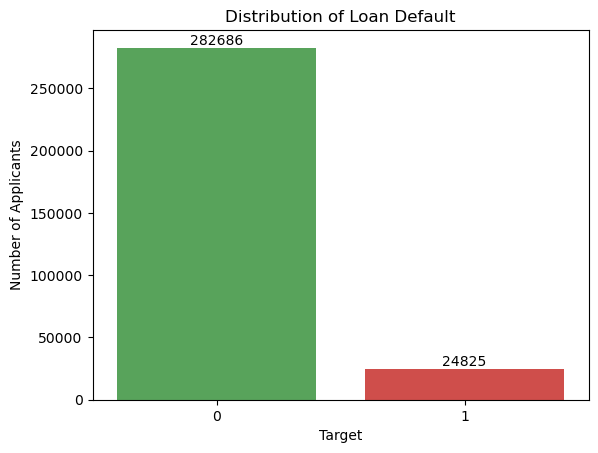

In [12]:

# Count Plot
import seaborn as sns
import matplotlib.pyplot as plt


ax = sns.countplot(
    data=df,
    x="TARGET",
    palette=["#4CAF50", "#E53935"]
)

# Add labels
for i in ax.containers:
    ax.bar_label(i)

plt.title("Distribution of Loan Default")
plt.xlabel("Target")
plt.ylabel("Number of Applicants")

plt.show()

In [13]:

# Missing Values Count

missing_count = df.isnull().sum()

missing_count

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [14]:
# =====================================================
# Missing Percentage
# =====================================================

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_percentage

SK_ID_CURR                     0.0
TARGET                         0.0
NAME_CONTRACT_TYPE             0.0
CODE_GENDER                    0.0
FLAG_OWN_CAR                   0.0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     13.5
AMT_REQ_CREDIT_BUREAU_WEEK    13.5
AMT_REQ_CREDIT_BUREAU_MON     13.5
AMT_REQ_CREDIT_BUREAU_QRT     13.5
AMT_REQ_CREDIT_BUREAU_YEAR    13.5
Length: 122, dtype: float64

In [15]:
# =====================================================
# Missing Value Summary
# =====================================================

missing_summary = pd.DataFrame({

    "Missing Count": missing_count,

    "Missing Percentage": missing_percentage

})

missing_summary

,Missing Count,Missing Percentage
SK_ID_CURR,0,0.0
TARGET,0,0.0
NAME_CONTRACT_TYPE,0,0.0
CODE_GENDER,0,0.0
FLAG_OWN_CAR,0,0.0
...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519,13.5
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.5
AMT_REQ_CREDIT_BUREAU_MON,41519,13.5
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.5


In [16]:
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]

missing_summary

,Missing Count,Missing Percentage
AMT_ANNUITY,12,0.00
AMT_GOODS_PRICE,278,0.09
NAME_TYPE_SUITE,1292,0.42
OWN_CAR_AGE,202929,65.99
OCCUPATION_TYPE,96391,31.35
...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519,13.50
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.50
AMT_REQ_CREDIT_BUREAU_MON,41519,13.50
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.50


In [17]:
missing_summary = missing_summary.sort_values(

    by="Missing Percentage",

    ascending=False

)

missing_summary.head(20)

,Missing Count,Missing Percentage
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


C:\Users\Lagan Somani\AppData\Local\Temp\ipykernel_23240\246438530.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


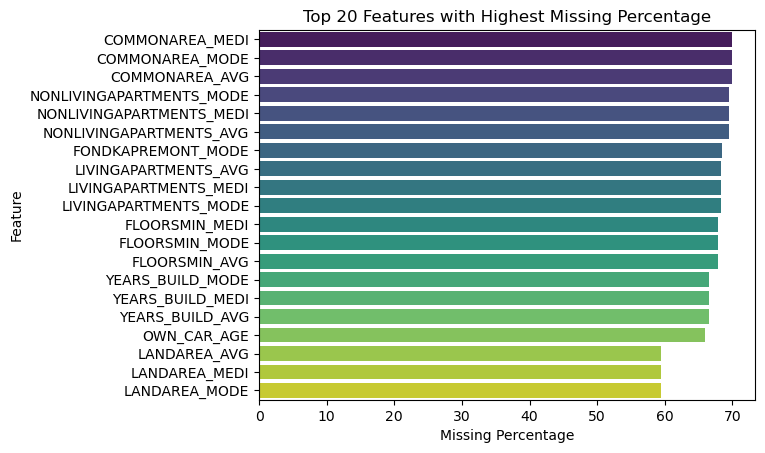

In [18]:


sns.barplot(
    data=missing_summary.head(20),
    x="Missing Percentage",
    y=missing_summary.head(20).index,
    palette="viridis"
)

plt.title("Top 20 Features with Highest Missing Percentage")

plt.xlabel("Missing Percentage")

plt.ylabel("Feature")

plt.show()

In [19]:
# =====================================================
# Summary Statistics for Important Numerical Features
# =====================================================

key_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

df[key_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


In [20]:
# =====================================================
# Check DAYS_EMPLOYED
# =====================================================

df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [21]:
# Number of applicants with placeholder value

(df["DAYS_EMPLOYED"] == 365243).sum()
# Percentage of applicants

(df["DAYS_EMPLOYED"] == 365243).mean() * 100

np.float64(18.00716071945394)

In [22]:
df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

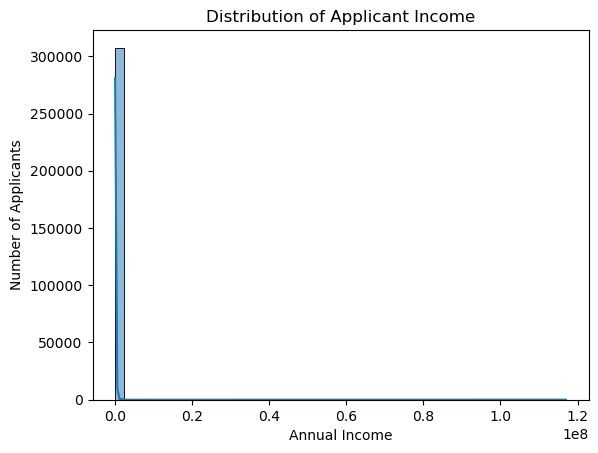

In [23]:
sns.histplot(data= df, x= "AMT_INCOME_TOTAL",bins = 50 , kde = True)
plt.title("Distribution of Applicant Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")
plt.show()

In [24]:
df["AMT_INCOME_TOTAL"].min()

25650.0

In [25]:
df["AMT_INCOME_TOTAL"].max()

117000000.0

In [26]:
df["AMT_INCOME_TOTAL"].quantile(
    [0.25,0.50,0.75,0.90,0.95,0.99,1.00]
)

0.25       112500.0
0.50       147150.0
0.75       202500.0
0.90       270000.0
0.95       337500.0
0.99       472500.0
1.00    117000000.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [27]:
# =====================================================
# Summary Statistics - DAYS_BIRTH
# =====================================================

df["DAYS_BIRTH"].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [28]:
age_years = (-df["DAYS_BIRTH"])/365
age_years.describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

In [29]:
print("Youngest Applicant :", age_years.min())

print("Oldest Applicant :", age_years.max())

Youngest Applicant : 20.517808219178082
Oldest Applicant : 69.12054794520547


In [30]:

# Gender Distribution

gender_counts = df["CODE_GENDER"].value_counts()

gender_percentage = (
    df["CODE_GENDER"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

gender_summary = pd.DataFrame({
    "Count": gender_counts,
    "Percentage": gender_percentage
})

gender_summary

,Count,Percentage
CODE_GENDER,,
F,202448,65.83
M,105059,34.16
XNA,4,0.00


In [31]:
education_counts = df["NAME_EDUCATION_TYPE"].value_counts()
education_percentage = (
    df["NAME_EDUCATION_TYPE"]
    .value_counts(normalize = True)
    .mul(100)
    .round(2)
)

education_summary = pd.DataFrame({
    "count" : education_counts,
    "percentage" : education_percentage
})
education_summary

,count,percentage
NAME_EDUCATION_TYPE,,
Secondary / secondary special,218391,71.02
Higher education,74863,24.34
Incomplete higher,10277,3.34
Lower secondary,3816,1.24
Academic degree,164,0.05


In [32]:
family_counts = df["NAME_FAMILY_STATUS"].value_counts()
family_percentage = (
    df["NAME_FAMILY_STATUS"]
    .value_counts()
    .mul(100)
    .round(2)
)
family_summary = pd.DataFrame({
    "count" : family_counts,
    "percentage" : family_percentage
})
family_summary

,count,percentage
NAME_FAMILY_STATUS,,
Married,196432,19643200
Single / not married,45444,4544400
Civil marriage,29775,2977500
Separated,19770,1977000
Widow,16088,1608800
Unknown,2,200


In [33]:
income_counts = df["NAME_INCOME_TYPE"].value_counts()
income_percentage = (
    df["NAME_INCOME_TYPE"]
    .value_counts()
    .mul(100)
    .round(2)
)

income_summary = pd.DataFrame({
    "count" : income_counts,
    "percentage" : income_percentage
})

income_summary
    


,count,percentage
NAME_INCOME_TYPE,,
Working,158774,15877400
Commercial associate,71617,7161700
Pensioner,55362,5536200
State servant,21703,2170300
Unemployed,22,2200
Student,18,1800
Businessman,10,1000
Maternity leave,5,500


In [34]:
occupation_count = df["OCCUPATION_TYPE"].value_counts()
occupation_percentage = (
    df["OCCUPATION_TYPE"]
    .value_counts()
    .mul(100)
    .round(2)
)

occupation_summary = pd.DataFrame({
    "count" : occupation_count,
    "percentage" : occupation_percentage
})
occupation_summary

,count,percentage
OCCUPATION_TYPE,,
Laborers,55186,5518600
Sales staff,32102,3210200
Core staff,27570,2757000
Managers,21371,2137100
Drivers,18603,1860300
High skill tech staff,11380,1138000
Accountants,9813,981300
Medicine staff,8537,853700
Security staff,6721,672100


In [35]:
# =====================================================
# Summary Statistics - Loan Amount
# =====================================================

df["AMT_CREDIT"].describe()

# =====================================================
# Missing Values
# =====================================================

print("Missing Values :", df["AMT_CREDIT"].isnull().sum())

Missing Values : 0


In [36]:
#create income group 
df["Income_Group"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=5,
    labels =[
        "Very Low",
        "low",
        "medium",
        "high",
        "very high"
    ]
)

In [37]:
#default rate by income group 
income_default = (
    df.groupby("Income_Group")["TARGET"]
    .mean()
    .mul(100)
    .round(2)
)
income_default

C:\Users\Lagan Somani\AppData\Local\Temp\ipykernel_23240\2457370097.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Income_Group")["TARGET"]


Income_Group
Very Low     8.21
low          8.59
medium       8.68
high         8.06
very high    6.52
Name: TARGET, dtype: float64

In [38]:
# =====================================================
# Create AGE Variable
# =====================================================

df["AGE"] = (-df["DAYS_BIRTH"]) / 365

In [39]:
# =====================================================
# Create Age Groups
# =====================================================

df["Age_Group"] = pd.cut(
    df["AGE"],
    bins=[20,30,40,50,60,70],
    labels=[
        "20-30",
        "30-40",
        "40-50",
        "50-60",
        "60-70"
    ]
)
# =====================================================
# Default Rate by Age Group
# =====================================================

age_default = (
    df.groupby("Age_Group")["TARGET"]
      .mean()
      .mul(100)
      .round(2)
)

age_default

C:\Users\Lagan Somani\AppData\Local\Temp\ipykernel_23240\2172367562.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["TARGET"]


Age_Group
20-30    11.46
30-40     9.58
40-50     7.65
50-60     6.13
60-70     4.92
Name: TARGET, dtype: float64

In [40]:
# =====================================================
# Default Rate by Education Level
# =====================================================

education_default = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

education_default

NAME_EDUCATION_TYPE
Lower secondary                  10.93
Secondary / secondary special     8.94
Incomplete higher                 8.48
Higher education                  5.36
Academic degree                   1.83
Name: TARGET, dtype: float64

In [41]:
# =====================================================
# Default Rate by Income Type
# =====================================================

income_type_default = (
    df.groupby("NAME_INCOME_TYPE")["TARGET"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

income_type_default

NAME_INCOME_TYPE
Maternity leave         40.00
Unemployed              36.36
Working                  9.59
Commercial associate     7.48
State servant            5.75
Pensioner                5.39
Businessman              0.00
Student                  0.00
Name: TARGET, dtype: float64

In [42]:
# =====================================================
# Default Rate by Occupation
# =====================================================

occupation_default = (
    df.groupby("OCCUPATION_TYPE")["TARGET"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

occupation_default

OCCUPATION_TYPE
Low-skill Laborers       17.15
Drivers                  11.33
Waiters/barmen staff     11.28
Security staff           10.74
Laborers                 10.58
Cooking staff            10.44
Sales staff               9.63
Cleaning staff            9.61
Realty agents             7.86
Secretaries               7.05
Medicine staff            6.70
Private service staff     6.60
IT staff                  6.46
HR staff                  6.39
Core staff                6.30
Managers                  6.21
High skill tech staff     6.16
Accountants               4.83
Name: TARGET, dtype: float64

In [43]:
# =====================================================
# Create Credit Amount Groups
# =====================================================

df["Credit_Group"] = pd.qcut(
    df["AMT_CREDIT"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)
# =====================================================
# Default Rate by Credit Group
# =====================================================

credit_default = (
    df.groupby("Credit_Group")["TARGET"]
      .mean()
      .mul(100)
      .round(2)
)

credit_default

C:\Users\Lagan Somani\AppData\Local\Temp\ipykernel_23240\2869885890.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Credit_Group")["TARGET"]


Credit_Group
Very Low      7.24
Low           9.17
Medium       10.05
High          7.85
Very High     6.08
Name: TARGET, dtype: float64

In [44]:
# =====================================================
# Create Loan Annuity Groups
# =====================================================

df["Annuity_Group"] = pd.qcut(
    df["AMT_ANNUITY"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)
# =====================================================
# Default Rate by Loan Annuity
# =====================================================

annuity_default = (
    df.groupby("Annuity_Group")["TARGET"]
      .mean()
      .mul(100)
      .round(2)
)

annuity_default

C:\Users\Lagan Somani\AppData\Local\Temp\ipykernel_23240\2338646553.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Annuity_Group")["TARGET"]


Annuity_Group
Very Low     6.95
Low          8.58
Medium       8.79
High         9.34
Very High    6.70
Name: TARGET, dtype: float64

In [45]:
# =====================================================
# Categorical Variables
# =====================================================

categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [46]:
# =====================================================
# Numerical Variables
# =====================================================

numeric_df = df.select_dtypes(include=["int64", "float64"])
# =====================================================
# Correlation Matrix
# =====================================================

correlation_matrix = numeric_df.corr()

correlation_matrix.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE
SK_ID_CURR,1.000000,-0.002108,-0.001129,-0.001820,-0.000343,-0.000433,-0.000232,0.000849,-0.001500,0.001366,...,0.000167,0.001073,0.000282,-0.002672,-0.002193,0.002099,0.000485,0.001025,0.004659,0.001500
TARGET,-0.002108,1.000000,0.019187,-0.003982,-0.030369,-0.012817,-0.039645,-0.037227,0.078239,-0.044932,...,-0.001358,0.000215,0.003709,0.000930,0.002704,0.000788,-0.012462,-0.002022,0.019930,-0.078239
CNT_CHILDREN,-0.001129,0.019187,1.000000,0.012882,0.002145,0.021374,-0.001827,-0.025573,0.330938,-0.239818,...,0.000864,0.000988,-0.002450,-0.000410,-0.000366,-0.002436,-0.010808,-0.007836,-0.041550,-0.330938
AMT_INCOME_TOTAL,-0.001820,-0.003982,0.012882,1.000000,0.156870,0.191657,0.159610,0.074796,0.027261,-0.064223,...,0.002408,0.000242,-0.000589,0.000709,0.002944,0.002387,0.024700,0.004859,0.011690,-0.027261
AMT_CREDIT,-0.000343,-0.030369,0.002145,0.156870,1.000000,0.770138,0.986968,0.099738,-0.055436,-0.066838,...,0.021082,0.031023,-0.016148,-0.003906,0.004238,-0.001275,0.054451,0.015925,-0.048448,0.055436


In [47]:

# Load Bureau Dataset


bureau = pd.read_csv(r"C:\Users\Lagan Somani\OneDrive\Desktop\credit risk\bureau.csv")
# =====================================================
# Shape of Dataset
# =====================================================

bureau.shape


(1716428, 17)

In [48]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [49]:
# =====================================================
# First Five Rows
# =====================================================

bureau.head()


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [50]:
bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08


In [51]:
print("Total Bureau Records :", len(bureau))

Total Bureau Records : 1716428


In [52]:
print("Unique Clients :", bureau["SK_ID_CURR"].nunique())

Unique Clients : 305811


In [53]:
avg_loans = len(bureau) / bureau["SK_ID_CURR"].nunique()

print("Average Previous Loans per Client :", round(avg_loans,2))

Average Previous Loans per Client : 5.61


In [54]:
# =====================================================
# Bureau Columns
# =====================================================

bureau.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

In [55]:
# =====================================================
# CREDIT_ACTIVE Distribution
# =====================================================

bureau["CREDIT_ACTIVE"].value_counts()

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

In [56]:
# =====================================================
# CREDIT_ACTIVE Percentage
# =====================================================

(
    bureau["CREDIT_ACTIVE"]
    .value_counts(normalize=True)
    * 100
).round(2)

CREDIT_ACTIVE
Closed      62.88
Active      36.74
Sold         0.38
Bad debt     0.00
Name: proportion, dtype: float64

In [57]:
# =====================================================
# CREDIT_TYPE Distribution
# =====================================================

bureau["CREDIT_TYPE"].value_counts()

CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                                  1
Interbank credit                                      1
Name: count, dtype: int64

In [58]:
# =====================================================
# CREDIT_TYPE Percentage
# =====================================================

(
    bureau["CREDIT_TYPE"]
    .value_counts(normalize=True)
    * 100
).round(2)

CREDIT_TYPE
Consumer credit                                 72.92
Credit card                                     23.43
Car loan                                         1.61
Mortgage                                         1.07
Microloan                                        0.72
Loan for business development                    0.12
Another type of loan                             0.06
Unknown type of loan                             0.03
Loan for working capital replenishment           0.03
Cash loan (non-earmarked)                        0.00
Real estate loan                                 0.00
Loan for the purchase of equipment               0.00
Loan for purchase of shares (margin lending)     0.00
Mobile operator loan                             0.00
Interbank credit                                 0.00
Name: proportion, dtype: float64

In [59]:
# =====================================================
# Summary Statistics
# =====================================================

bureau["AMT_CREDIT_SUM"].describe()

count    1.716415e+06
mean     3.549946e+05
std      1.149811e+06
min      0.000000e+00
25%      5.130000e+04
50%      1.255185e+05
75%      3.150000e+05
max      5.850000e+08
Name: AMT_CREDIT_SUM, dtype: float64

In [60]:
# =====================================================
# Missing Values
# =====================================================

print("Missing Values :", bureau["AMT_CREDIT_SUM"].isnull().sum())

Missing Values : 13


In [61]:
# =====================================================
# Summary Statistics
# =====================================================

bureau["AMT_CREDIT_SUM_DEBT"].describe()

count    1.458759e+06
mean     1.370851e+05
std      6.774011e+05
min     -4.705600e+06
25%      0.000000e+00
50%      0.000000e+00
75%      4.015350e+04
max      1.701000e+08
Name: AMT_CREDIT_SUM_DEBT, dtype: float64

In [62]:
# =====================================================
# Missing Values
# =====================================================

print("Missing Values :", bureau["AMT_CREDIT_SUM_DEBT"].isnull().sum())

Missing Values : 257669


In [63]:
# =====================================================
# Negative Outstanding Debt
# =====================================================

bureau[bureau["AMT_CREDIT_SUM_DEBT"] < 0]

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
21,222183,5714491,Active,currency 1,-784,0,1008.0,NaN,0.0,0,0.0,-411.615,411.615,0.0,Credit card,-694,NaN
87,119939,5714568,Closed,currency 1,-1447,0,-331.0,-1272.0,0.0,0,99000.0,-2692.170,137692.170,0.0,Credit card,-1272,NaN
88,119939,5714569,Closed,currency 1,-1390,0,-331.0,-1263.0,0.0,0,135000.0,-149.040,135149.040,0.0,Credit card,-1263,NaN
89,119939,5714570,Active,currency 1,-1390,0,-696.0,NaN,0.0,0,4500.0,-2.565,2.565,0.0,Credit card,-691,NaN
125,293201,5714621,Closed,currency 1,-2389,0,-1365.0,-1780.0,11250.0,0,225000.0,-701.280,225701.280,0.0,Credit card,-1780,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1715066,234436,5080818,Active,currency 1,-1000,0,832.0,NaN,0.0,0,0.0,-23.220,23.220,0.0,Credit card,-604,NaN
1715101,292494,5087696,Closed,currency 1,-2674,0,-1564.0,-1670.0,18900.0,0,225000.0,-36.180,22536.180,0.0,Credit card,-535,0.0
1715271,228547,5044511,Active,currency 1,-1663,0,1211.0,NaN,4720.5,0,135000.0,-1066.275,136066.275,0.0,Credit card,-640,67500.0
1715929,214607,5056789,Closed,currency 1,-1491,0,-374.0,-643.0,0.0,0,135000.0,-35.055,135035.055,0.0,Credit card,-643,NaN


In [64]:
# =====================================================
# Count Negative Debt
# =====================================================

print(
    "Negative Debt Records :",
    (bureau["AMT_CREDIT_SUM_DEBT"] < 0).sum()
)

Negative Debt Records : 8418


In [65]:
# =====================================================
# Examine Negative Debt Records
# =====================================================

negative_debt = bureau[bureau["AMT_CREDIT_SUM_DEBT"] < 0]

negative_debt.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
21,222183,5714491,Active,currency 1,-784,0,1008.0,NaN,0.0,0,0.0,-411.615,411.615,0.0,Credit card,-694,NaN
87,119939,5714568,Closed,currency 1,-1447,0,-331.0,-1272.0,0.0,0,99000.0,-2692.170,137692.170,0.0,Credit card,-1272,NaN
88,119939,5714569,Closed,currency 1,-1390,0,-331.0,-1263.0,0.0,0,135000.0,-149.040,135149.040,0.0,Credit card,-1263,NaN
89,119939,5714570,Active,currency 1,-1390,0,-696.0,NaN,0.0,0,4500.0,-2.565,2.565,0.0,Credit card,-691,NaN
125,293201,5714621,Closed,currency 1,-2389,0,-1365.0,-1780.0,11250.0,0,225000.0,-701.280,225701.280,0.0,Credit card,-1780,NaN


In [66]:
# =====================================================
# Summary Statistics
# =====================================================

bureau["CREDIT_DAY_OVERDUE"].describe()

count    1.716428e+06
mean     8.181666e-01
std      3.654443e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.792000e+03
Name: CREDIT_DAY_OVERDUE, dtype: float64

In [67]:
# =====================================================
# Loans with Overdue Payments
# =====================================================

print("Loans with Overdue Payments :",
      (bureau["CREDIT_DAY_OVERDUE"] > 0).sum())

print("Loans without Overdue Payments :",
      (bureau["CREDIT_DAY_OVERDUE"] == 0).sum())

Loans with Overdue Payments : 4217
Loans without Overdue Payments : 1712211


In [68]:
# =====================================================
# Missing Values
# =====================================================

print("Missing Values :", bureau["CREDIT_DAY_OVERDUE"].isnull().sum())


Missing Values : 0


In [69]:
# =====================================================
# Credit History in Years
# =====================================================

bureau["CREDIT_HISTORY_YEARS"] = (
    -bureau["DAYS_CREDIT"] / 365
)

bureau["CREDIT_HISTORY_YEARS"].describe()

count    1.716428e+06
mean     3.129062e+00
std      2.178534e+00
min      0.000000e+00
25%      1.298630e+00
50%      2.704110e+00
75%      4.564384e+00
max      8.005479e+00
Name: CREDIT_HISTORY_YEARS, dtype: float64

In [70]:
# =====================================================
# Feature 1 : Total Previous Loans
# =====================================================

total_previous_loans = (
    bureau.groupby("SK_ID_CURR")["SK_ID_BUREAU"]
          .count()
          .reset_index(name="TOTAL_PREVIOUS_LOANS")
)

total_previous_loans.head()

,SK_ID_CURR,TOTAL_PREVIOUS_LOANS
0,100001,7
1,100002,8
2,100003,4
3,100004,2
4,100005,3


In [71]:
# =====================================================
# Feature 2 : Active Loans
# =====================================================

active_loans = (
    bureau[bureau["CREDIT_ACTIVE"] == "Active"]
        .groupby("SK_ID_CURR")
        .size()
        .reset_index(name="ACTIVE_LOANS")
)

active_loans.head()

,SK_ID_CURR,ACTIVE_LOANS
0,100001,3
1,100002,2
2,100003,1
3,100005,2
4,100008,1


In [72]:
# =====================================================
# Feature 3 : Closed Loans
# =====================================================

closed_loans = (
    bureau[bureau["CREDIT_ACTIVE"] == "Closed"]
        .groupby("SK_ID_CURR")
        .size()
        .reset_index(name="CLOSED_LOANS")
)

closed_loans.head()

,SK_ID_CURR,CLOSED_LOANS
0,100001,4
1,100002,6
2,100003,3
3,100004,2
4,100005,1


In [73]:
# =====================================================
# Create Base Feature Table
# =====================================================

bureau_features = pd.DataFrame()

bureau_features["SK_ID_CURR"] = bureau["SK_ID_CURR"].unique()

bureau_features.head()

,SK_ID_CURR
0,215354
1,162297
2,402440
3,238881
4,222183


In [74]:
# =====================================================
# Total Previous Loans
# =====================================================

total_loans = (
    bureau.groupby("SK_ID_CURR")["SK_ID_BUREAU"]
          .count()
)

bureau_features["TOTAL_PREVIOUS_LOANS"] = (
    bureau_features["SK_ID_CURR"]
    .map(total_loans)
)

bureau_features.head()

,SK_ID_CURR,TOTAL_PREVIOUS_LOANS
0,215354,11
1,162297,6
2,402440,1
3,238881,8
4,222183,8


In [75]:
# =====================================================
# Active Loans
# =====================================================

active_loans = (
    bureau[bureau["CREDIT_ACTIVE"] == "Active"]
    .groupby("SK_ID_CURR")
    .size()
)

bureau_features["ACTIVE_LOANS"] = (
    bureau_features["SK_ID_CURR"]
    .map(active_loans)
)

In [76]:
# =====================================================
# Closed Loans
# =====================================================

closed_loans = (
    bureau[bureau["CREDIT_ACTIVE"] == "Closed"]
    .groupby("SK_ID_CURR")
    .size()
)

bureau_features["CLOSED_LOANS"] = (
    bureau_features["SK_ID_CURR"]
    .map(closed_loans)
)

In [77]:
# =====================================================
# Total Previous Credit
# =====================================================

total_credit = (
    bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM"]
    .sum()
)

bureau_features["TOTAL_PREVIOUS_CREDIT"] = (
    bureau_features["SK_ID_CURR"]
    .map(total_credit)
)

In [78]:
# =====================================================
# Maximum Previous Credit
# =====================================================

max_credit = (
    bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM"]
    .max()
)

bureau_features["MAX_PREVIOUS_CREDIT"] = (
    bureau_features["SK_ID_CURR"]
    .map(max_credit)
)

In [79]:
bureau_features.head()

,SK_ID_CURR,TOTAL_PREVIOUS_LOANS,ACTIVE_LOANS,CLOSED_LOANS,TOTAL_PREVIOUS_CREDIT,MAX_PREVIOUS_CREDIT
0,215354,11,6.0,5.0,5973945.30,2700000.0
1,162297,6,3.0,3.0,8230386.15,7033500.0
2,402440,1,1.0,NaN,89910.00,89910.0
3,238881,8,3.0,5.0,1285239.06,450000.0
4,222183,8,5.0,3.0,7158960.00,3709552.5


In [80]:
# =====================================================
# Total Outstanding Debt
# =====================================================

total_outstanding_debt = (
    bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"]
          .sum()
)

bureau_features["TOTAL_OUTSTANDING_DEBT"] = (
    bureau_features["SK_ID_CURR"]
    .map(total_outstanding_debt)
)

In [81]:
# =====================================================
# Average Outstanding Debt
# =====================================================

avg_outstanding_debt = (
    bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"]
          .mean()
)

bureau_features["AVG_OUTSTANDING_DEBT"] = (
    bureau_features["SK_ID_CURR"]
    .map(avg_outstanding_debt)
)

In [82]:
# =====================================================
# Maximum Outstanding Debt
# =====================================================

max_outstanding_debt = (
    bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"]
    .max()
)

bureau_features["MAX_OUTSTANDING_DEBT"] = (
    bureau_features["SK_ID_CURR"]
    .map(max_outstanding_debt)
)

In [83]:
# =====================================================
# Maximum Days Overdue
# =====================================================
max_days_overdue = (
    bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"]
          .max()
)

bureau_features["MAX_DAYS_OVERDUE"] = (
    bureau_features["SK_ID_CURR"]
    .map(max_days_overdue)
)


In [84]:
# =====================================================
# Average Days Overdue
# =====================================================

bureau_features["AVG_DAYS_OVERDUE"] = (
    bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"]
          .mean()
          .values
)

In [85]:
# =====================================================
# Number of Overdue Loans
# =====================================================

overdue_loans = (
    bureau[bureau["CREDIT_DAY_OVERDUE"] > 0]
    .groupby("SK_ID_CURR")
    .size()
)

bureau_features["TOTAL_OVERDUE_LOANS"] = (
    bureau_features["SK_ID_CURR"]
    .map(overdue_loans)
)

In [86]:
# =====================================================
# Average Days Overdue
# =====================================================

avg_days_overdue = (
    bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"]
          .mean()
)

bureau_features["AVG_DAYS_OVERDUE"] = (
    bureau_features["SK_ID_CURR"]
    .map(avg_days_overdue)
)

In [87]:
# =====================================================
# Oldest Credit
# =====================================================

oldest_credit = (
    bureau.groupby("SK_ID_CURR")["DAYS_CREDIT"]
    .min()
)

bureau_features["OLDEST_CREDIT"] = (
    bureau_features["SK_ID_CURR"]
    .map(oldest_credit)
)

In [88]:
# =====================================================
# Most Recent Credit
# =====================================================

most_recent_credit = (
    bureau.groupby("SK_ID_CURR")["DAYS_CREDIT"]
    .max()
)

bureau_features["MOST_RECENT_CREDIT"] = (
    bureau_features["SK_ID_CURR"]
    .map(most_recent_credit)
)

In [89]:
# =====================================================
# Debt-to-Credit Ratio
# =====================================================

bureau_features["DEBT_TO_CREDIT_RATIO"] = (
    bureau_features["TOTAL_OUTSTANDING_DEBT"] /
    bureau_features["TOTAL_PREVIOUS_CREDIT"]
)

In [90]:
# =====================================================
# Active Loan Ratio
# =====================================================

bureau_features["ACTIVE_LOAN_RATIO"] = (
    bureau_features["ACTIVE_LOANS"] /
    bureau_features["TOTAL_PREVIOUS_LOANS"]
)

In [91]:
bureau_features.head()

,SK_ID_CURR,TOTAL_PREVIOUS_LOANS,ACTIVE_LOANS,CLOSED_LOANS,TOTAL_PREVIOUS_CREDIT,MAX_PREVIOUS_CREDIT,TOTAL_OUTSTANDING_DEBT,AVG_OUTSTANDING_DEBT,MAX_OUTSTANDING_DEBT,MAX_DAYS_OVERDUE,AVG_DAYS_OVERDUE,TOTAL_OVERDUE_LOANS,OLDEST_CREDIT,MOST_RECENT_CREDIT,DEBT_TO_CREDIT_RATIO,ACTIVE_LOAN_RATIO
0,215354,11,6.0,5.0,5973945.30,2700000.0,284463.18,47410.53,171342.0,0,0.0,NaN,-1872,-43,0.047617,0.545455
1,162297,6,3.0,3.0,8230386.15,7033500.0,0.00,0.00,0.0,0,0.0,NaN,-2456,-277,0.000000,0.500000
2,402440,1,1.0,NaN,89910.00,89910.0,76905.00,76905.00,76905.0,0,0.0,NaN,-96,-96,0.855355,1.000000
3,238881,8,3.0,5.0,1285239.06,450000.0,552730.50,92121.75,520920.0,0,0.0,NaN,-2911,-95,0.430060,0.375000
4,222183,8,5.0,3.0,7158960.00,3709552.5,1185081.84,197513.64,1185493.5,0,0.0,NaN,-2744,-315,0.165538,0.625000


In [92]:
# =====================================================
# Merge Bureau Features
# =====================================================

df = df.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

df.shape

(307511, 142)

In [93]:
# =====================================================
# Missing Values After Merge
# =====================================================

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

TOTAL_OVERDUE_LOANS        304114
COMMONAREA_MODE            214865
COMMONAREA_MEDI            214865
COMMONAREA_AVG             214865
NONLIVINGAPARTMENTS_AVG    213514
                            ...  
AMT_GOODS_PRICE               278
Annuity_Group                  12
AMT_ANNUITY                    12
CNT_FAM_MEMBERS                 2
DAYS_LAST_PHONE_CHANGE          1
Length: 83, dtype: int64

In [94]:
# =====================================================
# Fill Bureau Count Features
# =====================================================

count_features = [
    "TOTAL_PREVIOUS_LOANS",
    "ACTIVE_LOANS",
    "CLOSED_LOANS",
    "TOTAL_OVERDUE_LOANS"
]

df[count_features] = df[count_features].fillna(0)

In [95]:
# =====================================================
# Check Missing Values Again
# =====================================================

df[count_features].isnull().sum()

TOTAL_PREVIOUS_LOANS    0
ACTIVE_LOANS            0
CLOSED_LOANS            0
TOTAL_OVERDUE_LOANS     0
dtype: int64

In [96]:
# =====================================================
# Has Bureau History
# =====================================================

df["HAS_BUREAU_HISTORY"] = (
    df["TOTAL_PREVIOUS_LOANS"] > 0
).astype(int)

In [97]:
# =====================================================
# Verify Bureau Features
# =====================================================

bureau_columns = [
    "SK_ID_CURR",
    "TOTAL_PREVIOUS_LOANS",
    "ACTIVE_LOANS",
    "CLOSED_LOANS",
    "TOTAL_PREVIOUS_CREDIT",
    "TOTAL_OUTSTANDING_DEBT",
    "TOTAL_OVERDUE_LOANS",
    "HAS_BUREAU_HISTORY"
]

df[bureau_columns].head()

,SK_ID_CURR,TOTAL_PREVIOUS_LOANS,ACTIVE_LOANS,CLOSED_LOANS,TOTAL_PREVIOUS_CREDIT,TOTAL_OUTSTANDING_DEBT,TOTAL_OVERDUE_LOANS,HAS_BUREAU_HISTORY
0,100002,8.0,2.0,6.0,865055.565,245781.0,0.0,1
1,100003,4.0,1.0,3.0,1017400.500,0.0,0.0,1
2,100004,2.0,0.0,2.0,189037.800,0.0,0.0,1
3,100006,0.0,0.0,0.0,NaN,NaN,0.0,0
4,100007,1.0,0.0,1.0,146250.000,0.0,0.0,1


In [98]:
# =====================================================
# Applicant Age
# =====================================================

df["AGE"] = (-df["DAYS_BIRTH"]) / 365

In [99]:
# =====================================================
# Fix DAYS_EMPLOYED
# =====================================================

df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

In [100]:
# =====================================================
# Employment Years
# =====================================================

df["EMPLOYMENT_YEARS"] = (
    -df["DAYS_EMPLOYED"] / 365
)

In [101]:
# =====================================================
# Credit to Income Ratio
# =====================================================

df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_INCOME_TOTAL"]
)

In [102]:
# =====================================================
# Annuity to Income Ratio
# =====================================================

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] /
    df["AMT_INCOME_TOTAL"]
)

In [103]:
# =====================================================
# Credit per Family Member
# =====================================================

df["CREDIT_PER_PERSON"] = (
    df["AMT_CREDIT"] /
    df["CNT_FAM_MEMBERS"]
)

In [104]:
# =====================================================
# Income per Family Member
# =====================================================

df["INCOME_PER_PERSON"] = (
    df["AMT_INCOME_TOTAL"] /
    df["CNT_FAM_MEMBERS"]
)

In [105]:
# =====================================================
# Loan to Goods Ratio
# =====================================================

df["LOAN_GOODS_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_GOODS_PRICE"]
)

In [106]:
new_features = [
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_PER_PERSON",
    "INCOME_PER_PERSON",
    "LOAN_GOODS_RATIO"
]

df[new_features].describe()

,AGE,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_PER_PERSON,INCOME_PER_PERSON,LOAN_GOODS_RATIO
count,307511.000000,252137.000000,307511.000000,307499.000000,3.075090e+05,3.075090e+05,307233.000000
mean,43.936973,6.531971,3.957570,0.180930,3.239496e+05,9.310588e+04,1.122995
std,11.956133,6.406466,2.689728,0.094574,2.590871e+05,1.013734e+05,0.124045
min,20.517808,-0.000000,0.004808,0.000224,6.750000e+03,2.812500e+03,0.150000
25%,34.008219,2.101370,2.018667,0.114782,1.355332e+05,4.725000e+04,1.000000
50%,43.150685,4.515068,3.265067,0.162833,2.550510e+05,7.500000e+04,1.118800
75%,53.923288,8.698630,5.159880,0.229067,4.373700e+05,1.125000e+05,1.198000
max,69.120548,49.073973,84.736842,1.875965,4.031032e+06,3.900000e+07,6.000000


In [107]:
# =====================================================
# Debt to Credit Ratio
# =====================================================

df["DEBT_TO_CREDIT_RATIO"] = (
    df["TOTAL_OUTSTANDING_DEBT"] /
    df["TOTAL_PREVIOUS_CREDIT"]
)

In [108]:
# =====================================================
# Active Loan Ratio
# =====================================================

df["ACTIVE_LOAN_RATIO"] = (
    df["ACTIVE_LOANS"] /
    df["TOTAL_PREVIOUS_LOANS"]
)

In [109]:
# =====================================================
# Overdue Loan Ratio
# =====================================================

df["OVERDUE_LOAN_RATIO"] = (
    df["TOTAL_OVERDUE_LOANS"] /
    df["TOTAL_PREVIOUS_LOANS"]
)

In [110]:
# =====================================================
# Employment to Age Ratio
# =====================================================

df["EMPLOYMENT_AGE_RATIO"] = (
    df["EMPLOYMENT_YEARS"] /
    df["AGE"]
)

In [111]:
# =====================================================
# Previous Credit per Loan
# =====================================================

df["AVG_CREDIT_PER_LOAN"] = (
    df["TOTAL_PREVIOUS_CREDIT"] /
    df["TOTAL_PREVIOUS_LOANS"]
)

In [112]:
new_features = [
    "DEBT_TO_CREDIT_RATIO",
    "ACTIVE_LOAN_RATIO",
    "OVERDUE_LOAN_RATIO",
    "EMPLOYMENT_AGE_RATIO",
    "AVG_CREDIT_PER_LOAN"
]

df[new_features].describe()

C:\Users\Lagan Somani\anaconda3\Lib\site-packages\numpy\_core\_methods.py:53: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,DEBT_TO_CREDIT_RATIO,ACTIVE_LOAN_RATIO,OVERDUE_LOAN_RATIO,EMPLOYMENT_AGE_RATIO,AVG_CREDIT_PER_LOAN
count,2.624720e+05,263491.000000,263491.000000,252137.000000,2.634910e+05
mean,NaN,0.412972,0.002976,0.156861,3.780769e+05
std,NaN,0.308404,0.035109,0.133549,8.916674e+05
min,-inf,0.000000,0.000000,-0.000000,0.000000e+00
25%,0.000000e+00,0.200000,0.000000,0.056099,1.035000e+05
50%,2.091433e-01,0.375000,0.000000,0.118733,1.955070e+05
75%,4.830696e-01,0.600000,0.000000,0.219170,3.941161e+05
max,inf,1.000000,1.000000,0.728811,1.980723e+08


In [113]:
# =====================================================
# Missing Values in Engineered Features
# =====================================================

engineered_features = [

    "AGE",
    "EMPLOYMENT_YEARS",

    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",

    "CREDIT_PER_PERSON",
    "INCOME_PER_PERSON",

    "LOAN_GOODS_RATIO",

    "DEBT_TO_CREDIT_RATIO",
    "ACTIVE_LOAN_RATIO",
    "OVERDUE_LOAN_RATIO",

    "EMPLOYMENT_AGE_RATIO",
    "AVG_CREDIT_PER_LOAN"

]

df[engineered_features].isnull().sum()

AGE                         0
EMPLOYMENT_YEARS        55374
CREDIT_INCOME_RATIO         0
ANNUITY_INCOME_RATIO       12
CREDIT_PER_PERSON           2
INCOME_PER_PERSON           2
LOAN_GOODS_RATIO          278
DEBT_TO_CREDIT_RATIO    45039
ACTIVE_LOAN_RATIO       44020
OVERDUE_LOAN_RATIO      44020
EMPLOYMENT_AGE_RATIO    55374
AVG_CREDIT_PER_LOAN     44020
dtype: int64

In [114]:
# =====================================================
# Check Infinite Values
# =====================================================

np.isinf(df[engineered_features]).sum()

AGE                      0
EMPLOYMENT_YEARS         0
CREDIT_INCOME_RATIO      0
ANNUITY_INCOME_RATIO     0
CREDIT_PER_PERSON        0
INCOME_PER_PERSON        0
LOAN_GOODS_RATIO         0
DEBT_TO_CREDIT_RATIO    64
ACTIVE_LOAN_RATIO        0
OVERDUE_LOAN_RATIO       0
EMPLOYMENT_AGE_RATIO     0
AVG_CREDIT_PER_LOAN      0
dtype: int64

In [115]:
# =====================================================
# Customers with Infinite Debt-to-Credit Ratio
# =====================================================

df[np.isinf(df["DEBT_TO_CREDIT_RATIO"])][
    [
        "SK_ID_CURR",
        "TOTAL_PREVIOUS_CREDIT",
        "TOTAL_OUTSTANDING_DEBT",
        "DEBT_TO_CREDIT_RATIO"
    ]
].head(10)

,SK_ID_CURR,TOTAL_PREVIOUS_CREDIT,TOTAL_OUTSTANDING_DEBT,DEBT_TO_CREDIT_RATIO
189,100219,0.0,-88.830,-inf
2955,103447,0.0,580.455,inf
7266,108460,0.0,-510.255,-inf
8589,110000,0.0,67.500,inf
30273,135137,0.0,1228.140,inf
39498,145736,0.0,-46.440,-inf
40486,146895,0.0,-2066.805,-inf
43234,150042,0.0,-2368.890,-inf
44127,151116,0.0,3427.740,inf
48658,156347,0.0,-7549.830,-inf


In [116]:
# =====================================================
# Investigate Customer
# =====================================================

bureau[
    bureau["SK_ID_CURR"] == 100219
][
    [
        "SK_ID_BUREAU",
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT"
    ]

]

,SK_ID_BUREAU,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT
1709304,5031754,0.0,-88.83


In [117]:
# =====================================================
# Investigate Customer with Positive Debt
# =====================================================

customer = 104882

bureau[
    bureau["SK_ID_CURR"] == customer
][
    [
        "SK_ID_BUREAU",
        "CREDIT_ACTIVE",
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT"
    ]
]

,SK_ID_BUREAU,CREDIT_ACTIVE,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT
92676,5205250,Active,0.0,0.0


In [118]:
# =====================================================
# Debt to Credit Ratio
# =====================================================

df["DEBT_TO_CREDIT_RATIO"] = np.where(
    df["TOTAL_PREVIOUS_CREDIT"] > 0,
    df["TOTAL_OUTSTANDING_DEBT"] / df["TOTAL_PREVIOUS_CREDIT"],
    np.nan
)

In [119]:
np.isinf(df["DEBT_TO_CREDIT_RATIO"]).sum()

np.int64(0)

In [120]:
print("Original Columns :", 122)
print("Current Columns  :", df.shape[1])
print("New Features     :", df.shape[1] - 122)

Original Columns : 122
Current Columns  : 152
New Features     : 30


In [121]:
from sklearn.model_selection import train_test_split

In [122]:
feature_columns = [col for col in df.columns if col != "TARGET"]

X = df.loc[:, feature_columns]
y = df["TARGET"]

In [123]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (307511, 151)
y Shape : (307511,)


In [124]:
# =====================================================
# Train Test Split
# =====================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [125]:
# =====================================================
# Check Dataset Shapes
# =====================================================

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (246008, 151)
X_test  : (61503, 151)
y_train : (246008,)
y_test  : (61503,)


In [126]:
# =====================================================
# Target Distribution
# =====================================================

print("Train Target Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Target Distribution")
print(y_test.value_counts(normalize=True) * 100)

Train Target Distribution
TARGET
0    91.927092
1     8.072908
Name: proportion, dtype: float64

Test Target Distribution
TARGET
0    91.927223
1     8.072777
Name: proportion, dtype: float64


In [127]:
# =====================================================
# Numerical and Categorical Features
# =====================================================

numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numerical Features :", len(numerical_features))
print("Categorical Features :", len(categorical_features))

Numerical Features : 135
Categorical Features : 16


In [128]:
# =====================================================
# Check Identifier Columns
# =====================================================

print("SK_ID_CURR" in X_train.columns)

# =====================================================
# Remove Identifier Column
# =====================================================

X_train = X_train.drop(columns=["SK_ID_CURR"])
X_test = X_test.drop(columns=["SK_ID_CURR"])

True


In [129]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (246008, 150)
X_test  : (61503, 150)


In [130]:

!pip install optbinning

In [131]:
!pip install scorecardpy

In [132]:
import scorecardpy as sc

In [133]:
# =====================================================
# Create Bins for AMT_CREDIT
# =====================================================

train_data = X_train.copy()
train_data["TARGET"] = y_train

train_data["AMT_CREDIT_BIN"] = pd.qcut(
    train_data["AMT_CREDIT"],
    q=5,
    duplicates="drop"
)

In [134]:
train_data["AMT_CREDIT_BIN"].value_counts().sort_index()

AMT_CREDIT_BIN
(44999.999, 254700.0]    51901
(254700.0, 432567.0]     46525
(432567.0, 604204.2]     49179
(604204.2, 900000.0]     51227
(900000.0, 4050000.0]    47176
Name: count, dtype: int64

In [135]:
# =====================================================
# Good and Bad Counts
# =====================================================

woe_table = train_data.groupby("AMT_CREDIT_BIN")["TARGET"].agg(
    Total="count",
    Bad="sum"
)

woe_table["Good"] = woe_table["Total"] - woe_table["Bad"]

woe_table

C:\Users\Lagan Somani\AppData\Local\Temp\ipykernel_23240\869886613.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  woe_table = train_data.groupby("AMT_CREDIT_BIN")["TARGET"].agg(


,Total,Bad,Good
AMT_CREDIT_BIN,,,
"(44999.999, 254700.0]",51901,3768,48133
"(254700.0, 432567.0]",46525,4278,42247
"(432567.0, 604204.2]",49179,4950,44229
"(604204.2, 900000.0]",51227,4001,47226
"(900000.0, 4050000.0]",47176,2863,44313


In [136]:
woe_table["Good_Dist"] = (
    woe_table["Good"] /
    woe_table["Good"].sum()
)

In [137]:
woe_table["Bad_Dist"] = (
    woe_table["Bad"] /
    woe_table["Bad"].sum()
)

In [138]:
woe_table

,Total,Bad,Good,Good_Dist,Bad_Dist
AMT_CREDIT_BIN,,,,,
"(44999.999, 254700.0]",51901,3768,48133,0.212838,0.189728
"(254700.0, 432567.0]",46525,4278,42247,0.186811,0.215408
"(432567.0, 604204.2]",49179,4950,44229,0.195575,0.249245
"(604204.2, 900000.0]",51227,4001,47226,0.208828,0.201460
"(900000.0, 4050000.0]",47176,2863,44313,0.195947,0.144159


In [139]:
# =====================================================
# Weight of Evidence (WOE)
# =====================================================

import numpy as np

woe_table["WOE"] = np.log(
    woe_table["Good_Dist"] /
    woe_table["Bad_Dist"]
)

woe_table

,Total,Bad,Good,Good_Dist,Bad_Dist,WOE
AMT_CREDIT_BIN,,,,,,
"(44999.999, 254700.0]",51901,3768,48133,0.212838,0.189728,0.114942
"(254700.0, 432567.0]",46525,4278,42247,0.186811,0.215408,-0.142434
"(432567.0, 604204.2]",49179,4950,44229,0.195575,0.249245,-0.242489
"(604204.2, 900000.0]",51227,4001,47226,0.208828,0.201460,0.035918
"(900000.0, 4050000.0]",47176,2863,44313,0.195947,0.144159,0.306926


In [140]:
# =====================================================
# Information Value (IV)
# =====================================================

woe_table["IV"] = (
    (woe_table["Good_Dist"] - woe_table["Bad_Dist"])
    * woe_table["WOE"]
)

woe_table

,Total,Bad,Good,Good_Dist,Bad_Dist,WOE,IV
AMT_CREDIT_BIN,,,,,,,
"(44999.999, 254700.0]",51901,3768,48133,0.212838,0.189728,0.114942,0.002656
"(254700.0, 432567.0]",46525,4278,42247,0.186811,0.215408,-0.142434,0.004073
"(432567.0, 604204.2]",49179,4950,44229,0.195575,0.249245,-0.242489,0.013014
"(604204.2, 900000.0]",51227,4001,47226,0.208828,0.201460,0.035918,0.000265
"(900000.0, 4050000.0]",47176,2863,44313,0.195947,0.144159,0.306926,0.015895


In [141]:
# =====================================================
# Total Information Value
# =====================================================

total_iv = woe_table["IV"].sum()

print("Information Value (IV):", round(total_iv, 4))

Information Value (IV): 0.0359


In [142]:
train_data = X_train.copy()
train_data["TARGET"] = y_train

In [143]:
train_data.shape

(246008, 151)

In [144]:
import pandas as pd
import scorecardpy as sc
import sklearn

print("Pandas:", pd.__version__)
print("Scorecardpy:", sc.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 2.2.3
Scorecardpy: 0.1.9.7
Scikit-learn: 1.6.1


In [145]:
train_data.select_dtypes(include="category").columns

Index(['Income_Group', 'Age_Group', 'Credit_Group', 'Annuity_Group'], dtype='object')

In [156]:
category_cols = train_data.select_dtypes(include="category").columns
train_data[category_cols] = train_data[category_cols].astype("object")

In [157]:
# =====================================================
# Generate WOE Bins
# =====================================================

bins = sc.woebin(
    dt=train_data,
    y="TARGET"
)

[INFO] creating woe binning ...


C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `d

>>> There are 1 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
ORGANIZATION_TYPE
>>> Continue the binning process?
1: yes 
2: no


Selection:  1


C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\woebin.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .stack().replace('missing', np.nan) \
C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).groupby(['variable', 'rowid', 'bin_chr'], group_keys=False).agg({'bad':sum,'good':sum})\
C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\woebin.py:141: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, 

Binning on 246008 rows and 151 columns in 00:09:10


C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index().assign(bin=lambda x: x['bstbin'])\
C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, th

In [158]:
type(bins)

dict

In [159]:
len(bins)

150

In [160]:
# =====================================================
# AMT_CREDIT WOE Table
# =====================================================

bins["AMT_CREDIT"]

,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,AMT_CREDIT,"[-inf,150000.0)",14528,0.059055,13654,874,0.060160,-0.316225,0.005176,0.053956,150000.0,False
1,AMT_CREDIT,"[150000.0,300000.0)",58207,0.236606,53629,4578,0.078650,-0.028346,0.000188,0.053956,300000.0,False
2,AMT_CREDIT,"[300000.0,650000.0)",81251,0.330278,73009,8242,0.101439,0.251142,0.023147,0.053956,650000.0,False
3,AMT_CREDIT,"[650000.0,900000.0)",39834,0.161922,36798,3036,0.076216,-0.062421,0.000615,0.053956,900000.0,False
4,AMT_CREDIT,"[900000.0,1350000.0)",39062,0.158783,36505,2557,0.065460,-0.226133,0.007388,0.053956,1350000.0,False
5,AMT_CREDIT,"[1350000.0,inf)",13126,0.053356,12553,573,0.043654,-0.654347,0.017442,0.053956,inf,False


In [161]:
import pandas as pd

iv_summary = pd.DataFrame({
    "Variable": list(bins.keys()),
    "IV": [bins[var]["total_iv"].iloc[0] for var in bins]
})

iv_summary = iv_summary.sort_values(
    by="IV",
    ascending=False
).reset_index(drop=True)

iv_summary.head(20)

,Variable,IV
0,EXT_SOURCE_3,0.321738
1,EXT_SOURCE_2,0.295554
2,EXT_SOURCE_1,0.146336
3,EMPLOYMENT_YEARS,0.109928
4,DAYS_EMPLOYED,0.109425
5,DEBT_TO_CREDIT_RATIO,0.098959
6,EMPLOYMENT_AGE_RATIO,0.090488
7,ACTIVE_LOAN_RATIO,0.087270
8,AGE,0.085801
9,DAYS_BIRTH,0.085588


In [162]:
# =====================================================
# Keep Variables with IV >= 0.02
# =====================================================

selected_features = iv_summary[
    iv_summary["IV"] >= 0.02
]["Variable"].tolist()

print("Selected Features :", len(selected_features))
print("Dropped Features  :", len(iv_summary) - len(selected_features))

Selected Features : 70
Dropped Features  : 80


In [163]:
# =====================================================
# Selected Numerical Features
# =====================================================

selected_numeric = [
    col for col in selected_features
    if col in numerical_features
]

print("Selected Numerical Features:", len(selected_numeric))

Selected Numerical Features: 61


In [164]:
X_train[selected_numeric].select_dtypes(exclude=np.number).columns.tolist()

['Age_Group', 'Credit_Group']

In [165]:
# =====================================================
# Selected Numeric Features
# =====================================================

selected_numeric = (
    X_train[selected_features]
    .select_dtypes(include=np.number)
    .columns.tolist()
)

print("Numeric Features:", len(selected_numeric))

Numeric Features: 59


In [166]:
# =====================================================
# Correlation Matrix
# =====================================================

corr_matrix = X_train[selected_numeric].corr().abs()

In [167]:
# =====================================================
# Highly Correlated Features
# =====================================================

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
    .reset_index()
)

high_corr.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_corr = high_corr[
    high_corr["Correlation"] >= 0.80
].sort_values(
    by="Correlation",
    ascending=False
)

high_corr

,Feature_1,Feature_2,Correlation
171,EMPLOYMENT_YEARS,DAYS_EMPLOYED,1.000000
436,AGE,DAYS_BIRTH,1.000000
1008,FLOORSMAX_MEDI,FLOORSMAX_AVG,0.996983
1606,ENTRANCES_AVG,ENTRANCES_MEDI,0.996911
1411,ELEVATORS_AVG,ELEVATORS_MEDI,0.996319
...,...,...,...
1390,APARTMENTS_MEDI,ELEVATORS_MODE,0.826966
1365,APARTMENTS_AVG,ELEVATORS_MODE,0.824274
1194,TOTALAREA_MODE,ELEVATORS_MODE,0.822899
1436,ELEVATORS_MEDI,APARTMENTS_MODE,0.810200


In [168]:
# =====================================================
# Create IV Dictionary
# =====================================================

iv_dict = dict(zip(iv_summary["Variable"], iv_summary["IV"]))

In [169]:
# =====================================================
# Add IV to Correlated Features
# =====================================================

comparison = high_corr.copy()

comparison["IV_1"] = comparison["Feature_1"].map(iv_dict)
comparison["IV_2"] = comparison["Feature_2"].map(iv_dict)

comparison.head(20)

,Feature_1,Feature_2,Correlation,IV_1,IV_2
171,EMPLOYMENT_YEARS,DAYS_EMPLOYED,1.000000,0.109928,0.109425
436,AGE,DAYS_BIRTH,1.000000,0.085801,0.085588
1008,FLOORSMAX_MEDI,FLOORSMAX_AVG,0.996983,0.037555,0.037549
1606,ENTRANCES_AVG,ENTRANCES_MEDI,0.996911,0.026937,0.026593
1411,ELEVATORS_AVG,ELEVATORS_MEDI,0.996319,0.031737,0.031506
1305,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995472,0.032930,0.032792
1360,APARTMENTS_AVG,APARTMENTS_MEDI,0.995430,0.031986,0.031768
1708,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.994335,0.021431,0.021316
1540,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,0.994314,0.028401,0.028103
1691,NONLIVINGAREA_AVG,NONLIVINGAREA_MEDI,0.991197,0.022594,0.022108


In [170]:
# =====================================================
# Feature to Drop
# =====================================================

comparison["Drop"] = np.where(
    comparison["IV_1"] >= comparison["IV_2"],
    comparison["Feature_2"],
    comparison["Feature_1"]
)

comparison.head(20)

,Feature_1,Feature_2,Correlation,IV_1,IV_2,Drop
171,EMPLOYMENT_YEARS,DAYS_EMPLOYED,1.000000,0.109928,0.109425,DAYS_EMPLOYED
436,AGE,DAYS_BIRTH,1.000000,0.085801,0.085588,DAYS_BIRTH
1008,FLOORSMAX_MEDI,FLOORSMAX_AVG,0.996983,0.037555,0.037549,FLOORSMAX_AVG
1606,ENTRANCES_AVG,ENTRANCES_MEDI,0.996911,0.026937,0.026593,ENTRANCES_MEDI
1411,ELEVATORS_AVG,ELEVATORS_MEDI,0.996319,0.031737,0.031506,ELEVATORS_MEDI
1305,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995472,0.032930,0.032792,LIVINGAREA_MEDI
1360,APARTMENTS_AVG,APARTMENTS_MEDI,0.995430,0.031986,0.031768,APARTMENTS_MEDI
1708,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.994335,0.021431,0.021316,BASEMENTAREA_MEDI
1540,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,0.994314,0.028401,0.028103,YEARS_BEGINEXPLUATATION_AVG
1691,NONLIVINGAREA_AVG,NONLIVINGAREA_MEDI,0.991197,0.022594,0.022108,NONLIVINGAREA_MEDI


In [171]:
# =====================================================
# Final Variables to Drop
# =====================================================

drop_features = comparison["Drop"].unique().tolist()

print("Variables to Drop:", len(drop_features))
drop_features

Variables to Drop: 25


['DAYS_EMPLOYED',
 'DAYS_BIRTH',
 'FLOORSMAX_AVG',
 'ENTRANCES_MEDI',
 'ELEVATORS_MEDI',
 'LIVINGAREA_MEDI',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BEGINEXPLUATATION_AVG',
 'NONLIVINGAREA_MEDI',
 'FLOORSMAX_MODE',
 'AMT_CREDIT',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'BASEMENTAREA_MODE',
 'APARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'LIVINGAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'EMPLOYMENT_AGE_RATIO',
 'TOTAL_OUTSTANDING_DEBT',
 'REGION_RATING_CLIENT',
 'LIVINGAREA_AVG',
 'APARTMENTS_AVG',
 'ELEVATORS_AVG']

In [172]:
drop_features.remove("AMT_CREDIT")

drop_features.remove("EMPLOYMENT_AGE_RATIO")

drop_features.remove("TOTAL_OUTSTANDING_DEBT")

In [173]:
# =====================================================
# Final Selected Features
# =====================================================

final_features = [
    col for col in selected_features
    if col not in drop_features
]

print("Final Features:", len(final_features))

Final Features: 48


In [174]:
# =====================================================
# Final Train & Test Dataset
# =====================================================

X_train_final = X_train[final_features].copy()

X_test_final = X_test[final_features].copy()

In [175]:
print(X_train_final.shape)
print(X_test_final.shape)

(246008, 48)
(61503, 48)


In [176]:
final_bins = {
    k: v for k, v in bins.items()
    if k in final_features
}

print("Bins kept:", len(final_bins))

Bins kept: 48


In [177]:
train_data = X_train_final.copy()
train_data["TARGET"] = y_train

test_data = X_test_final.copy()
test_data["TARGET"] = y_test

In [178]:
train_woe = sc.woebin_ply(train_data, final_bins)

test_woe = sc.woebin_ply(test_data, final_bins)

[INFO] converting into woe values ...
Woe transformating on 246008 rows and 48 columns in 00:01:31
[INFO] converting into woe values ...
Woe transformating on 61503 rows and 48 columns in 00:00:23


In [179]:
# =====================================================
# Features and Target
# =====================================================

X_train_model = train_woe.drop(columns=["TARGET"])
y_train_model = train_woe["TARGET"]

X_test_model = test_woe.drop(columns=["TARGET"])
y_test_model = test_woe["TARGET"]

print(X_train_model.shape)
print(X_test_model.shape)

(246008, 48)
(61503, 48)


In [180]:
# =====================================================
# Import Libraries
# =====================================================

import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [181]:
# =====================================================
# Add Constant
# =====================================================

X_train_sm = sm.add_constant(X_train_model)

X_test_sm = sm.add_constant(X_test_model)

In [182]:
# =====================================================
# Logistic Regression
# =====================================================

logit_model = sm.Logit(
    y_train_model,
    X_train_sm
)

result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.249617
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245959
Method:                           MLE   Df Model:                           48
Date:                Wed, 12 Aug 2026   Pseudo R-squ.:                  0.1102
Time:                        23:20:18   Log-Likelihood:                -61408.
converged:                       True   LL-Null:                       -69017.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -2.4363      0.008   -297.04

In [183]:
# =====================================================
# Variables with p-value > 0.05
# =====================================================

p_values = result.pvalues

insignificant = p_values[p_values > 0.05]

print(insignificant.sort_values())

FLOORSMAX_MEDI_woe                0.062683
WALLSMATERIAL_MODE_woe            0.093717
ENTRANCES_AVG_woe                 0.095354
EMPLOYMENT_YEARS_woe              0.100955
REG_CITY_NOT_WORK_CITY_woe        0.110120
AMT_ANNUITY_woe                   0.137591
NONLIVINGAREA_AVG_woe             0.202846
MAX_OUTSTANDING_DEBT_woe          0.229102
OLDEST_CREDIT_woe                 0.299504
REGION_POPULATION_RELATIVE_woe    0.366783
BASEMENTAREA_AVG_woe              0.603851
EMERGENCYSTATE_MODE_woe           0.637573
ACTIVE_LOAN_RATIO_woe             0.643483
AVG_CREDIT_PER_LOAN_woe           0.713643
CLOSED_LOANS_woe                  0.923880
TOTALAREA_MODE_woe                0.944137
dtype: float64


In [184]:
print("Variables to remove:", len(insignificant))

Variables to remove: 16


In [185]:
# =====================================================
# P-values
# =====================================================

p_values = result.pvalues.to_frame(name="P_Value")

p_values.sort_values(by="P_Value", ascending=False)

,P_Value
TOTALAREA_MODE_woe,9.441372e-01
CLOSED_LOANS_woe,9.238800e-01
AVG_CREDIT_PER_LOAN_woe,7.136434e-01
ACTIVE_LOAN_RATIO_woe,6.434834e-01
EMERGENCYSTATE_MODE_woe,6.375732e-01
BASEMENTAREA_AVG_woe,6.038512e-01
REGION_POPULATION_RELATIVE_woe,3.667826e-01
OLDEST_CREDIT_woe,2.995035e-01
MAX_OUTSTANDING_DEBT_woe,2.291016e-01
NONLIVINGAREA_AVG_woe,2.028460e-01


In [228]:
# =====================================================
# Significant Variables + VIF-Based Feature Removal
# =====================================================

significant_features = p_values[
    p_values["P_Value"] <= 0.05
].index.tolist()

# Remove intercept
significant_features.remove("const")

# Remove highly correlated / redundant variables
significant_features.remove("Age_Group_woe")
significant_features.remove("AMT_GOODS_PRICE_woe")

print("Significant Features:", len(significant_features))
print("Removed for VIF / Redundancy:")
print(" - Age_Group_woe")
print(" - AMT_GOODS_PRICE_woe")

Significant Features: 30
Removed for VIF / Redundancy:
 - Age_Group_woe
 - AMT_GOODS_PRICE_woe


In [230]:
# =====================================================
# Keep Significant Variables
# =====================================================

X_train_sig = X_train_sm[["const"] + significant_features]

X_test_sig = X_test_sm[["const"] + significant_features]

In [231]:
# =====================================================
# Refit Logistic Regression
# =====================================================

logit_model_final = sm.Logit(
    y_train_model,
    X_train_sig
)

result_final = logit_model_final.fit()

print(result_final.summary())

Optimization terminated successfully.
         Current function value: 0.249773
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245977
Method:                           MLE   Df Model:                           30
Date:                Thu, 13 Aug 2026   Pseudo R-squ.:                  0.1097
Time:                        00:17:14   Log-Likelihood:                -61446.
converged:                       True   LL-Null:                       -69017.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -2.4359      0.008   -297.28

In [232]:
# =====================================================
# Variance Inflation Factor (VIF)
# =====================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X_train_sig.columns

vif["VIF"] = [
    variance_inflation_factor(X_train_sig.values, i)
    for i in range(X_train_sig.shape[1])
]

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
20,TOTAL_OUTSTANDING_DEBT_woe,4.319085
25,FLAG_EMP_PHONE_woe,4.176438
6,AVG_OUTSTANDING_DEBT_woe,3.878230
15,HOUSETYPE_MODE_woe,3.502501
7,YEARS_BEGINEXPLUATATION_MEDI_woe,3.470517
27,AMT_CREDIT_woe,3.355942
13,Credit_Group_woe,3.283579
5,NAME_INCOME_TYPE_woe,2.892792
17,DEBT_TO_CREDIT_RATIO_woe,2.344610
16,ORGANIZATION_TYPE_woe,2.266771


MODEL EVALUATION

In [233]:
# =====================================================
# Predict Default Probability
# =====================================================

y_pred_prob = result_final.predict(X_test_sig)

y_pred_prob[:10]

256571    0.066032
191493    0.060001
103497    0.188872
130646    0.090763
211898    0.091316
130549    0.155839
287975    0.010888
144906    0.011553
102173    0.304050
254495    0.071782
dtype: float64

In [234]:
# =====================================================
# Predicted Class
# =====================================================

y_pred = (y_pred_prob >= 0.5).astype(int)

y_pred[:10]

256571    0
191493    0
103497    0
130646    0
211898    0
130549    0
287975    0
144906    0
102173    0
254495    0
dtype: int64

### Model Evaluation and Classification Threshold

The dataset is highly imbalanced, with substantially more non-default observations than default observations. Therefore, classification metrics calculated at the conventional probability threshold of 0.50, such as precision, recall, and F1-score, should be interpreted with caution.

At a 0.50 threshold, the model produces a very low recall because only observations with predicted default probability above 0.50 are classified as defaults. In credit risk applications, many risky customers may have predicted probabilities below this threshold.

Therefore, threshold-independent measures such as ROC-AUC, KS statistic, and Gini coefficient are given greater importance for evaluating the model's ability to discriminate between default and non-default customers.

The 0.50-threshold metrics are retained for completeness, while the overall model assessment focuses primarily on ROC-AUC, KS and Gini.

In [235]:
# =====================================================
# Model Evaluation
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", round(accuracy_score(y_test_model, y_pred), 4))
print("Precision:", round(precision_score(y_test_model, y_pred), 4))
print("Recall   :", round(recall_score(y_test_model, y_pred), 4))
print("F1 Score :", round(f1_score(y_test_model, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test_model, y_pred_prob), 4))

Accuracy : 0.9195
Precision: 0.5789
Recall   : 0.0089
F1 Score : 0.0175
ROC AUC  : 0.7477


In [236]:
# =====================================================
# Confusion Matrix
# =====================================================

cm = confusion_matrix(y_test_model, y_pred)

print(cm)

[[56506    32]
 [ 4921    44]]


In [237]:
# =====================================================
# Classification Report
# =====================================================

from sklearn.metrics import classification_report

print(classification_report(y_test_model, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.58      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.75      0.50      0.49     61503
weighted avg       0.89      0.92      0.88     61503



In [238]:
# =====================================================
# KS Statistic
# =====================================================

from scipy.stats import ks_2samp

ks = ks_2samp(
    y_pred_prob[y_test_model == 0],
    y_pred_prob[y_test_model == 1]
).statistic

print("KS Statistic :", round(ks, 4))

KS Statistic : 0.3673


In [196]:
# =====================================================
# Gini Coefficient
# =====================================================

from sklearn.metrics import roc_auc_score

gini = 2 * roc_auc_score(y_test_model, y_pred_prob) - 1

print("Gini Coefficient :", round(gini, 4))

Gini Coefficient : 0.4958


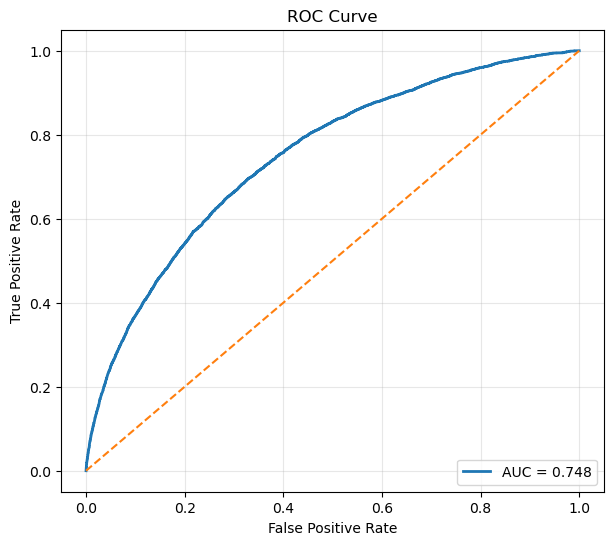

In [239]:
# =====================================================
# ROC Curve
# =====================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_model, y_pred_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test_model, y_pred_prob):.3f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [240]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_sig.drop(columns="const"),
    y_train_model
)

LogisticRegression(max_iter=1000, random_state=42)

In [241]:
card = sc.scorecard(
    bins=final_bins,
    model=lr,
    xcolumns=significant_features
)

In [242]:
card


{'basepoints':      variable  bin  points
 0  basepoints  NaN   563.0,
 'EMPLOYMENT_AGE_RATIO':                  variable          bin  points
 114  EMPLOYMENT_AGE_RATIO      missing    14.0
 115  EMPLOYMENT_AGE_RATIO  [-inf,0.08)   -10.0
 116  EMPLOYMENT_AGE_RATIO  [0.08,0.11)    -7.0
 117  EMPLOYMENT_AGE_RATIO  [0.11,0.19)    -1.0
 118  EMPLOYMENT_AGE_RATIO  [0.19,0.36)     7.0
 119  EMPLOYMENT_AGE_RATIO   [0.36,inf)    19.0,
 'OCCUPATION_TYPE':             variable                                                bin  \
 161  OCCUPATION_TYPE                                            missing   
 162  OCCUPATION_TYPE  Accountants%,%IT staff%,%Managers%,%High skill...   
 163  OCCUPATION_TYPE  Cleaning staff%,%Sales staff%,%Cooking staff%,...   
 164  OCCUPATION_TYPE  Drivers%,%Waiters/barmen staff%,%Low-skill Lab...   
 
      points  
 161     3.0  
 162     4.0  
 163    -4.0  
 164    -6.0  ,
 'DAYS_LAST_PHONE_CHANGE':                  variable                bin  points
 0  DAYS_LA

In [243]:
# =====================================================
# Generate Credit Score for Training Customers
# =====================================================

train_score = sc.scorecard_ply(
    train_data,
    card,
    print_step=0
)

train_score.head()

C:\Users\Lagan Somani\anaconda3\Lib\site-packages\scorecardpy\scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)


,score
181648,579.0
229245,510.0
122525,565.0
306311,561.0
300658,480.0


In [244]:
# =====================================================
# Credit Score Summary
# =====================================================

train_score.describe()

,score
count,246008.000000
mean,588.937339
std,68.989866
min,317.000000
25%,542.000000
50%,590.000000
75%,637.000000
max,866.000000


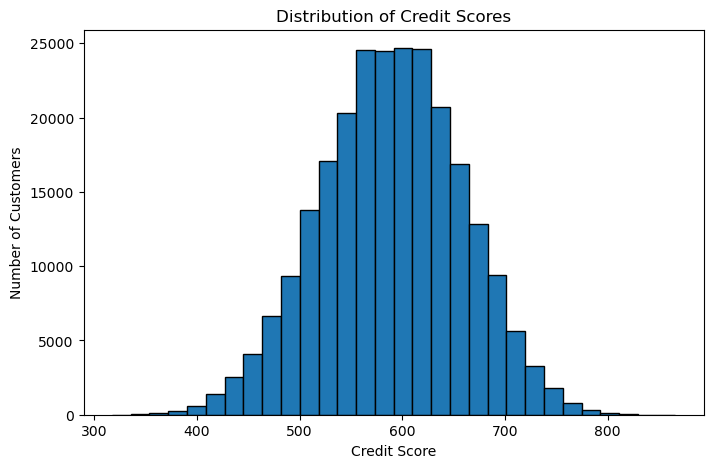

In [245]:
# =====================================================
# Distribution of Credit Scores
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_score["score"], bins=30, edgecolor="black")

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

In [246]:
# =====================================================
# Credit Score Summary
# =====================================================

train_score["score"].describe()

count    246008.000000
mean        588.937339
std          68.989866
min         317.000000
25%         542.000000
50%         590.000000
75%         637.000000
max         866.000000
Name: score, dtype: float64

In [248]:
# =====================================================
# Create Risk Bands
# =====================================================

train_score["Risk_Band"] = pd.cut(
    train_score["score"],
    bins=[320, 500, 600, 700, 900],
    labels=[
        "High Risk",
        "Medium Risk",
        "Low Risk",
        "Very Low Risk"
    ],
    include_lowest=True
)

In [249]:
# =====================================================
# Risk Band Distribution
# =====================================================

risk_summary = train_score["Risk_Band"].value_counts().sort_index()

print(risk_summary)

Risk_Band
High Risk         25604
Medium Risk      111778
Low Risk          96262
Very Low Risk     12363
Name: count, dtype: int64


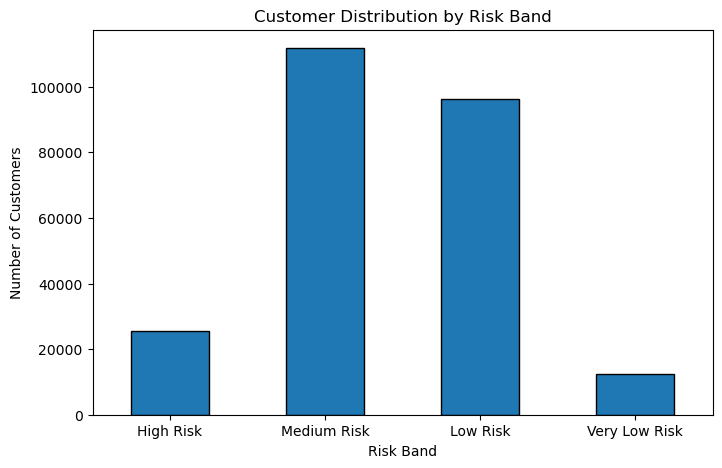

In [250]:
# =====================================================
# Risk Band Distribution Plot
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

risk_summary.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Customer Distribution by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [251]:
# =====================================================
# Risk Band Validation - Actual Default Rate
# =====================================================

train_score["TARGET"] = y_train_model.values

risk_band_validation = (
    train_score
    .groupby("Risk_Band", observed=True)["TARGET"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
    .reset_index()
)

risk_band_validation["Default_Rate"] = (
    risk_band_validation["Default_Rate"] * 100
).round(2)

risk_band_validation

,Risk_Band,Customers,Defaults,Default_Rate
0,High Risk,25604,6540,25.54
1,Medium Risk,111778,10305,9.22
2,Low Risk,96262,2855,2.97
3,Very Low Risk,12363,159,1.29


Credit limit recommendation engine

In [252]:
print(final_features)

['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'EMPLOYMENT_YEARS', 'DEBT_TO_CREDIT_RATIO', 'EMPLOYMENT_AGE_RATIO', 'ACTIVE_LOAN_RATIO', 'AGE', 'MOST_RECENT_CREDIT', 'Age_Group', 'OCCUPATION_TYPE', 'OLDEST_CREDIT', 'ORGANIZATION_TYPE', 'LOAN_GOODS_RATIO', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE', 'AMT_CREDIT', 'REGION_RATING_CLIENT_W_CITY', 'AVG_OUTSTANDING_DEBT', 'NAME_EDUCATION_TYPE', 'DAYS_LAST_PHONE_CHANGE', 'CLOSED_LOANS', 'CODE_GENDER', 'MAX_OUTSTANDING_DEBT', 'FLOORSMAX_MEDI', 'TOTAL_OUTSTANDING_DEBT', 'DAYS_ID_PUBLISH', 'Credit_Group', 'TOTALAREA_MODE', 'FLAG_EMP_PHONE', 'REGION_POPULATION_RELATIVE', 'REG_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_3', 'YEARS_BEGINEXPLUATATION_MEDI', 'DAYS_REGISTRATION', 'ENTRANCES_AVG', 'ACTIVE_LOANS', 'WALLSMATERIAL_MODE', 'AVG_CREDIT_PER_LOAN', 'REG_CITY_NOT_LIVE_CITY', 'NAME_FAMILY_STATUS', 'MAX_PREVIOUS_CREDIT', 'AMT_ANNUITY', 'EMERGENCYSTATE_MODE', 'NONLIVINGAREA_AVG', 'OWN_CAR_AGE', 'BASEMENTAREA_AVG', 'HOUSETYPE_MODE']


In [253]:
# =====================================================
# Bank Lending Policy
# =====================================================

# Maximum acceptable Probability of Default (PD)

RISK_THRESHOLD = 0.10      # 10%

print("Maximum Acceptable PD:", RISK_THRESHOLD)

Maximum Acceptable PD: 0.1


In [254]:
# =====================================================
# Candidate Credit Limits
# =====================================================

import numpy as np

credit_limits = np.arange(
    100000,
    1100000,
    100000
)

credit_limits

array([ 100000,  200000,  300000,  400000,  500000,  600000,  700000,
        800000,  900000, 1000000])

In [255]:
applicant = train_data.iloc[[0]].copy()

applicant.head()

,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1,EMPLOYMENT_YEARS,DEBT_TO_CREDIT_RATIO,EMPLOYMENT_AGE_RATIO,ACTIVE_LOAN_RATIO,AGE,MOST_RECENT_CREDIT,Age_Group,...,REG_CITY_NOT_LIVE_CITY,NAME_FAMILY_STATUS,MAX_PREVIOUS_CREDIT,AMT_ANNUITY,EMERGENCYSTATE_MODE,NONLIVINGAREA_AVG,OWN_CAR_AGE,BASEMENTAREA_AVG,HOUSETYPE_MODE,TARGET
181648,0.622922,0.289573,0.384582,2.591781,0.258209,0.076923,0.4,33.693151,-592.0,30-40,...,0,Married,184500.0,13189.5,No,0.0,NaN,0.1613,block of flats,0


In [257]:
train_score.columns.tolist()

['score', 'Risk_Band', 'TARGET']

In [258]:
# =====================================================
# Decision Dataset
# =====================================================

decision_data = X_train.copy()

decision_data["Credit_Score"] = train_score["score"].values
decision_data["Risk_Band"] = train_score["Risk_Band"].values
decision_data["PD"] = result_final.predict(X_train_sig)

decision_data.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,ANNUITY_INCOME_RATIO,CREDIT_PER_PERSON,INCOME_PER_PERSON,LOAN_GOODS_RATIO,OVERDUE_LOAN_RATIO,EMPLOYMENT_AGE_RATIO,AVG_CREDIT_PER_LOAN,Credit_Score,Risk_Band,PD
181648,Cash loans,F,N,N,2,90000.0,227520.0,13189.5,180000.0,Unaccompanied,...,0.146550,56880.0,22500.0,1.264000,0.0,0.076923,113580.00,579.0,Medium Risk,0.064924
229245,Cash loans,M,Y,Y,0,90000.0,161730.0,13095.0,135000.0,Unaccompanied,...,0.145500,80865.0,45000.0,1.198000,NaN,0.005984,NaN,510.0,Medium Risk,0.153594
122525,Cash loans,M,N,Y,0,135000.0,728847.0,26307.0,553500.0,"Spouse, partner",...,0.194867,728847.0,135000.0,1.316797,0.0,0.085254,274812.75,565.0,Medium Risk,0.079618
306311,Cash loans,M,N,N,0,135000.0,474183.0,34636.5,391500.0,Unaccompanied,...,0.256567,474183.0,135000.0,1.211195,0.0,0.092800,399285.00,561.0,Medium Risk,0.082925
300658,Cash loans,F,N,Y,0,180000.0,254700.0,27558.0,225000.0,Unaccompanied,...,0.153100,254700.0,180000.0,1.132000,NaN,0.115131,NaN,480.0,High Risk,0.217300


In [260]:
decision_data[[
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "Credit_Score",
    "Risk_Band",
    "PD"
]].head()

,AMT_INCOME_TOTAL,AMT_CREDIT,Credit_Score,Risk_Band,PD
181648,90000.0,227520.0,579.0,Medium Risk,0.064924
229245,90000.0,161730.0,510.0,Medium Risk,0.153594
122525,135000.0,728847.0,565.0,Medium Risk,0.079618
306311,135000.0,474183.0,561.0,Medium Risk,0.082925
300658,180000.0,254700.0,480.0,High Risk,0.217300


In [261]:
credit_policy = {

    "Very Low Risk": {
        "income_multiplier":6,
        "pd_limit":0.03,
        "decision":"APPROVE"
    },

    "Low Risk": {
        "income_multiplier":4,
        "pd_limit":0.07,
        "decision":"APPROVE"
    },

    "Medium Risk": {
        "income_multiplier":2,
        "pd_limit":0.12,
        "decision":"MANUAL REVIEW"
    },

    "High Risk": {
        "income_multiplier":1,
        "pd_limit":1.00,
        "decision":"REJECT / LOW LIMIT"
    }

}

In [263]:
# ============================================================
# Customer Credit Limit Recommendation Engine
# ============================================================

def recommend_customer(customer):

    # --------------------------------------------------------
    # 1. Customer Information
    # --------------------------------------------------------

    score = float(customer["Credit_Score"])
    pd = float(customer["PD"])
    risk = customer["Risk_Band"]

    income = float(customer["AMT_INCOME_TOTAL"])
    current_credit = float(customer["AMT_CREDIT"])


    # --------------------------------------------------------
    # 2. Risk-Based Credit Policy
    # --------------------------------------------------------

    policy = {

        "Very Low Risk": {
            "multiplier": 3.0,
            "decision": "APPROVE / INCREASE"
        },

        "Low Risk": {
            "multiplier": 2.5,
            "decision": "APPROVE"
        },

        "Medium Risk": {
            "multiplier": 2.0,
            "decision": "MANUAL REVIEW"
        },

        "High Risk": {
            "multiplier": 1.0,
            "decision": "REJECT / LOW LIMIT"
        },

        "Very High Risk": {
            "multiplier": 0.5,
            "decision": "REJECT / LOW LIMIT"
        }
    }


    # --------------------------------------------------------
    # 3. Get Risk Policy
    # --------------------------------------------------------

    if risk in policy:

        multiplier = policy[risk]["multiplier"]
        decision = policy[risk]["decision"]

    else:

        # Conservative fallback
        multiplier = 1.0
        decision = "MANUAL REVIEW"


    # --------------------------------------------------------
    # 4. Calculate Income-Based Recommended Limit
    # --------------------------------------------------------

    recommended_limit = income * multiplier


    # --------------------------------------------------------
    # 5. Risk-Based Limit Adjustment
    # --------------------------------------------------------

    if risk in ["High Risk", "Very High Risk"]:

        # High-risk customers cannot receive an increase
        recommended_limit = min(
            recommended_limit,
            current_credit
        )

    elif risk == "Medium Risk":

        # Medium-risk customers can have their
        # existing limit reduced
        recommended_limit = recommended_limit

    else:

        # Low-risk customers can retain or increase
        # their existing credit limit
        recommended_limit = max(
            recommended_limit,
            current_credit
        )


    # --------------------------------------------------------
    # 6. Prevent Negative / Zero Limits
    # --------------------------------------------------------

    recommended_limit = max(
        recommended_limit,
        0
    )


    # --------------------------------------------------------
    # 7. Round Recommended Limit
    # --------------------------------------------------------

    recommended_limit = round(
        recommended_limit,
        -2
    )


    # --------------------------------------------------------
    # 8. Generate Reasons
    # --------------------------------------------------------

    reasons = []


    # Credit score reason
    if score >= 700:

        reasons.append(
            "Strong credit score"
        )

    elif score >= 600:

        reasons.append(
            "Moderate credit score"
        )

    else:

        reasons.append(
            "Low credit score"
        )


    # Default probability reason
    if pd <= 0.05:

        reasons.append(
            "Very low probability of default"
        )

    elif pd <= 0.10:

        reasons.append(
            "Acceptable default probability"
        )

    else:

        reasons.append(
            "Elevated default probability"
        )


    # Income reason
    if income >= 300000:

        reasons.append(
            "Stable income supports repayment"
        )

    else:

        reasons.append(
            "Limited repayment capacity"
        )


    # Risk reason
    if risk in ["High Risk", "Very High Risk"]:

        reasons.append(
            "Risk-based limit restriction applied"
        )

    elif risk == "Medium Risk":

        reasons.append(
            "Moderate risk requires cautious credit allocation"
        )

    else:

        reasons.append(
            "Lower risk supports maintaining or increasing credit"
        )


    # --------------------------------------------------------
    # 9. Return Recommendation
    # --------------------------------------------------------

    return {

        "Credit Score": round(score, 0),

        "PD": round(pd, 4),

        "Risk Band": risk,

        "Annual Income": income,

        "Current Credit": current_credit,

        "Recommended Credit Limit": recommended_limit,

        "Decision": decision,

        "Reasons": reasons
    }

In [265]:
# ============================================================
# Phase 2: Portfolio-Level Credit Limit Validation
# ============================================================

sample_data = decision_data.sample(
    n=min(100, len(decision_data)),
    random_state=42
)

results = []

for _, customer in sample_data.iterrows():

    result = recommend_customer(customer)

    results.append({
        "Risk_Band": result["Risk Band"],
        "Current_Credit": result["Current Credit"],
        "Recommended_Limit": result["Recommended Credit Limit"],
        "Decision": result["Decision"]
    })

phase2_results = pd.DataFrame(results)

# Calculate change in credit limit
phase2_results["Limit_Change"] = (
    phase2_results["Recommended_Limit"]
    - phase2_results["Current_Credit"]
)

# Classify recommendation
phase2_results["Change_Type"] = np.where(
    phase2_results["Limit_Change"] > 0,
    "Increased",
    np.where(
        phase2_results["Limit_Change"] < 0,
        "Decreased",
        "Unchanged"
    )
)

phase2_results.head(10)

,Risk_Band,Current_Credit,Recommended_Limit,Decision,Limit_Change,Change_Type
0,Low Risk,1381113.0,1381100.0,APPROVE,-13.0,Decreased
1,High Risk,227520.0,45000.0,REJECT / LOW LIMIT,-182520.0,Decreased
2,High Risk,848745.0,157500.0,REJECT / LOW LIMIT,-691245.0,Decreased
3,Very Low Risk,1264428.0,1264400.0,APPROVE / INCREASE,-28.0,Decreased
4,Low Risk,202500.0,326200.0,APPROVE,123700.0,Increased
5,Medium Risk,225000.0,198000.0,MANUAL REVIEW,-27000.0,Decreased
6,Low Risk,855000.0,855000.0,APPROVE,0.0,Unchanged
7,Medium Risk,808650.0,360000.0,MANUAL REVIEW,-448650.0,Decreased
8,High Risk,1147711.5,225000.0,REJECT / LOW LIMIT,-922711.5,Decreased
9,Low Risk,225000.0,393800.0,APPROVE,168800.0,Increased


In [266]:
# ============================================================
# Recommendation Change Summary by Risk Band
# ============================================================

phase2_summary = (
    phase2_results
    .groupby("Risk_Band")["Change_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
)

phase2_summary

Change_Type,Decreased,Increased,Unchanged
Risk_Band,,,
High Risk,100.00,0.00,0.00
Low Risk,17.07,43.90,39.02
Medium Risk,80.49,19.51,0.00
Very Low Risk,25.00,25.00,50.00


In [264]:
customer = decision_data.iloc[0]

recommend_customer(customer)

{'Credit Score': 579.0,
 'PD': 0.0649,
 'Risk Band': 'Medium Risk',
 'Annual Income': 90000.0,
 'Current Credit': 227520.0,
 'Recommended Credit Limit': 180000.0,
 'Decision': 'MANUAL REVIEW',
 'Reasons': ['Low credit score',
  'Acceptable default probability',
  'Limited repayment capacity',
  'Moderate risk requires cautious credit allocation']}

In [225]:
decision_data.head(20)

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,ANNUITY_INCOME_RATIO,CREDIT_PER_PERSON,INCOME_PER_PERSON,LOAN_GOODS_RATIO,OVERDUE_LOAN_RATIO,EMPLOYMENT_AGE_RATIO,AVG_CREDIT_PER_LOAN,Credit_Score,Risk_Band,PD
181648,Cash loans,F,N,N,2,90000.0,227520.0,13189.5,180000.0,Unaccompanied,...,0.146550,56880.0,22500.0,1.264000,0.0,0.076923,113580.000000,573.0,Medium Risk,0.067619
229245,Cash loans,M,Y,Y,0,90000.0,161730.0,13095.0,135000.0,Unaccompanied,...,0.145500,80865.0,45000.0,1.198000,NaN,0.005984,NaN,515.0,Medium Risk,0.142122
122525,Cash loans,M,N,Y,0,135000.0,728847.0,26307.0,553500.0,"Spouse, partner",...,0.194867,728847.0,135000.0,1.316797,0.0,0.085254,274812.750000,559.0,Medium Risk,0.084540
306311,Cash loans,M,N,N,0,135000.0,474183.0,34636.5,391500.0,Unaccompanied,...,0.256567,474183.0,135000.0,1.211195,0.0,0.092800,399285.000000,558.0,Medium Risk,0.083492
300658,Cash loans,F,N,Y,0,180000.0,254700.0,27558.0,225000.0,Unaccompanied,...,0.153100,254700.0,180000.0,1.132000,NaN,0.115131,NaN,476.0,High Risk,0.222076
201033,Revolving loans,F,N,Y,0,74250.0,225000.0,11250.0,225000.0,Unaccompanied,...,0.151515,112500.0,37125.0,1.000000,0.0,NaN,154450.285714,680.0,Low Risk,0.015917
86445,Cash loans,M,Y,N,1,157500.0,360000.0,13842.0,360000.0,Unaccompanied,...,0.087886,120000.0,52500.0,1.000000,0.0,0.154779,146250.000000,543.0,Medium Risk,0.106672
225267,Cash loans,F,N,Y,1,202500.0,1350189.0,39609.0,1179000.0,Unaccompanied,...,0.195600,450063.0,67500.0,1.145198,NaN,0.108018,NaN,563.0,Medium Risk,0.076995
42927,Cash loans,F,N,N,1,81000.0,225000.0,10953.0,225000.0,Unaccompanied,...,0.135222,75000.0,27000.0,1.000000,0.0,0.138833,122141.812500,586.0,Medium Risk,0.056812
240820,Revolving loans,M,Y,Y,0,112500.0,135000.0,6750.0,135000.0,"Spouse, partner",...,0.060000,67500.0,56250.0,1.000000,0.0,0.006563,299844.000000,565.0,Medium Risk,0.076210


In [226]:
# =====================================================
# Test Recommendation Engine Across Risk Bands
# =====================================================

for risk in decision_data["Risk_Band"].dropna().unique():

    customer = decision_data[
        decision_data["Risk_Band"] == risk
    ].iloc[0]

    result = recommend_customer(customer)

    print("\n" + "=" * 50)
    print("Risk Band:", result["Risk Band"])
    print("Current Credit:", result["Current Credit"])
    print("Recommended Limit:", result["Recommended Credit Limit"])
    print("Decision:", result["Decision"])


Risk Band: Medium Risk
Current Credit: 227520.0
Recommended Limit: 180000.0
Decision: MANUAL REVIEW

Risk Band: High Risk
Current Credit: 254700.0
Recommended Limit: 180000.0
Decision: REJECT / LOW LIMIT

Risk Band: Low Risk
Current Credit: 225000.0
Recommended Limit: 225000.0
Decision: APPROVE

Risk Band: Very Low Risk
Current Credit: 526491.0
Recommended Limit: 526500.0
Decision: APPROVE / INCREASE
